# Exploring the graph dataset

This notebook inspects a graph dataset built by `framework/make_graphs.py` (a list of `Data` objects). Each graph represents one simulated beam with 30 nodes.

The notebook first prints the shapes of the stored fields, then plots the topological node features (Laplacian eigenvectors, degree centrality), the sensing mask, and the sparse measured signals for one random system, and finally draws the topology with `networkx`.

In [54]:
import torch
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import networkx as nx


In [ ]:

graphs_name = Path('example.pt')

graph_dir = '../graphs' / graphs_name

g = torch.load(graph_dir, weights_only = False )

Data(x=[30, 8], edge_index=[2, 168], edge_attr=[168, 7], num_nodes=30, acc=[30, 2500], vel=[30, 2500], disp=[30, 2500], mask=[30], y=[30, 2500], sys_id=0, M=[29, 29], C=[29, 29], K=[29, 29], F=[30, 2500])


## Fields and shapes

Everything that is stored on a single graph, with its shape.

In [56]:
for key, val in g[0]:
    if hasattr(val, "shape"):
        print(f"{key:12s} {tuple(val.shape)}")
    else:
        print(f"{key:12s} {val}  (scalar)")

x            (30, 8)
edge_index   (2, 168)
edge_attr    (168, 7)
num_nodes    30  (scalar)
acc          (30, 2500)
vel          (30, 2500)
disp         (30, 2500)
mask         (30,)
y            (30, 2500)
sys_id       0  (scalar)
M            (29, 29)
C            (29, 29)
K            (29, 29)
F            (30, 2500)


## Node features and measured signals for one random system

The next cell plots the two purely topological node features:

- the 3 Laplacian eigenvectors (`x[:, 4:7]`) are the graph's lowest eigenvectors, the topological counterpart of mode shapes in structural dynamics.
- the degree centrality (`x[:, 7]`) is uniform along the chain except at the sensed nodes, since those carry the extra shortcut edges.

It then shows the sensing `mask` and the model input `y`: only the sensed rows of `y` are non-zero, and those are the only signals the GNN ever sees. Everything else is what it has to reconstruct.

In [ ]:
rng = np.random.default_rng(0)
rand = rng.integers(len(g))
example = g[rand]

fs = 500
nodes = range(example.x.shape[0])
time = np.linspace(0, example.y.shape[1]/fs, example.y.shape[1])

# laplacian eigenvectors
eig_vecs = example.x[:, 4:7]
plt.figure(figsize=(8, 4))
for i in range(3):
    plt.plot(nodes, eig_vecs[:, i], marker='o', ms=3, label=f'eigenvector {i+1}')
plt.xlabel('node')
plt.ylabel('value')
plt.title(f'Laplacian eigenvectors - system {rand}')
plt.legend()
plt.grid(True, which='major')
plt.tight_layout()
plt.show()

# degree centrality
plt.figure(figsize=(8, 4))
plt.plot(nodes, example.x[:, 7], marker='o', ms=3)
plt.xlabel('node')
plt.ylabel(r'$C_g$')
plt.title(f'Degree centrality - system {rand}')
plt.grid(True, which='major')
plt.tight_layout()
plt.show()

# mask
print(f'sparse sensing mask\n {example.mask}')

# measured responses
fig, (ax_t, ax_f) = plt.subplots(2, 1, figsize=(8, 8))

for node in nodes:
    yn = example.y[node].cpu().numpy()
    if yn.max() > 0:
        ax_t.plot(time, yn, label=f'node {node+1}')
        fx, pxx = welch(yn, fs=fs, nperseg=fs/2, noverlap=fs/4)
        ax_f.semilogy(fx, pxx, label=f'node {node+1}')

ax_t.set(xlabel='time (s)', ylabel='response', title=f'Measured responses - system {rand}')
ax_f.set(xlabel='frequency (Hz)', ylabel='PSD', title=f'Power spectral density - system {rand}')
ax_t.legend(); ax_f.legend()
ax_t.grid(True, which='major')
ax_f.grid(True, which='major')
fig.tight_layout()
plt.show()

## Graph topology

The last cell draws the connectivity with `networkx`: the chain of the FEM mesh, plus the shortcut edges that connect each sensor location to all other locations.

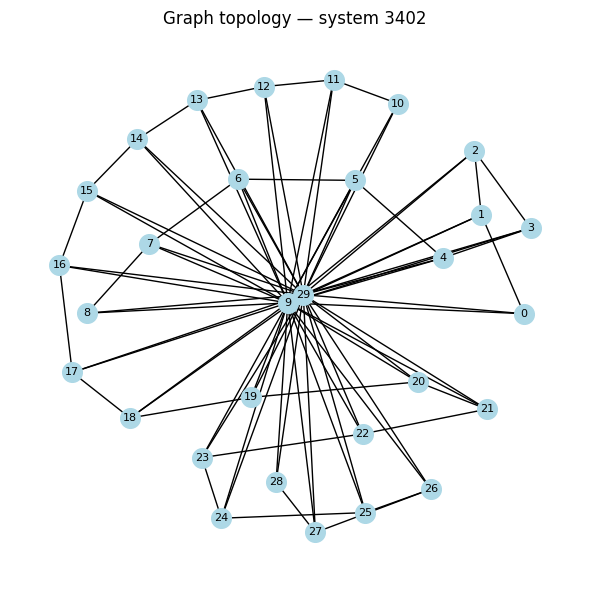

In [ ]:

edges = example.edge_index.cpu().numpy().T  
G = nx.Graph()
G.add_nodes_from(range(example.num_nodes))
G.add_edges_from(edges)

plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G, seed=0)
nx.draw_networkx(G, pos, node_size=200, node_color='lightblue', with_labels=True, font_size=8)
plt.title(f'Graph topology - system {rand}')
plt.axis('off')
plt.tight_layout()
plt.show()